<a href="https://colab.research.google.com/github/ddezouza/Data201_DanielaMelo/blob/main/DanielaMelo_Assignment5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Load the Dataset


In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

iris = sns.load_dataset("iris")
iris.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


1. Print the number of observations in the dataset

In [2]:
print(len(iris))

150


2. Print the Column Names

In [3]:
print(iris.columns)

Index(['sepal_length', 'sepal_width', 'petal_length', 'petal_width',
       'species'],
      dtype='object')


3. count how many observations exist for each species

In [5]:
iris["species"].value_counts()

,count
species,
setosa,50
versicolor,50
virginica,50


## Part 1 -- Bootstrap Resampling
### Task 1 --- Basic Statistics

Compute the following for sepal_length:

- mean

In [17]:
print(f'Mean:{np.mean(iris['sepal_length']):.4}')

Mean:5.843


- median

In [15]:
print(f'Median:{np.median(iris["sepal_length"])}')

Median:5.8


- standard deviation

In [13]:
print(f'Standard Deviation: {np.std(iris["sepal_length"]):.3}')

Standard Deviation: 0.825


### Task 2 --- Bootstrap the Mean

Perform 5,000 bootstrap resamples.

Procedure:

1. Sample the dataset with replacement.
2. Each sample must contain 150 observations.
3. Compute the mean sepal length for each resample.
4. Store the results.

Bootstrapped Mean: 5.84
Bootstrapped Std: 0.0679


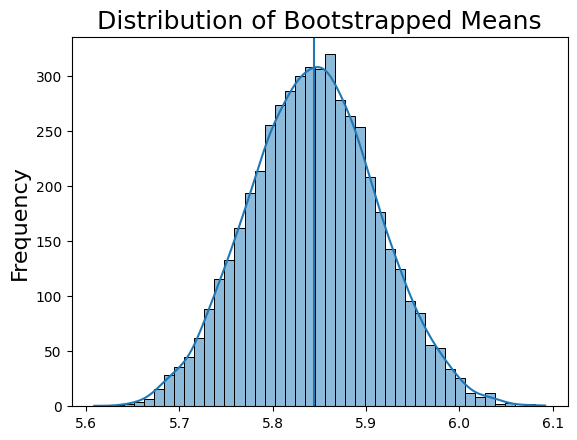

In [10]:
n_bootstrap = 5000

bootstrap_means = []
for b in range(n_bootstrap):
    bootstrap_means.append(np.mean(np.random.choice(iris["sepal_length"], size=150, replace=True)))
bootstrap_means = np.array(bootstrap_means)

sns.histplot(bootstrap_means, kde=True, label='Bootstrap')
plt.axvline(x=np.mean(bootstrap_means), ymin=0, ymax=1, linestyle='-')
plt.title('Distribution of Bootstrapped Means', fontsize=18)
plt.ylabel('Frequency', fontsize=16)

print(f'Bootstrapped Mean: {np.mean(bootstrap_means):.3}')
print(f'Bootstrapped Std: {np.std(bootstrap_means):.3}')

### Task 3 --- Confidence Interval
Using the bootstrap results, compute the 95% confidence interval using the percentile method:

CI = [2.5%, 97.5%]

Report:

- Bootstrap mean
- Lower bound
- Upper bound

In [11]:
print(f"Bootstrap Mean: {np.mean(bootstrap_means):.3f}")
print(f"95% CI Lower Bound: {np.percentile(bootstrap_means,2.5):.3f}")
print(f"95% CI Upper Bound: {np.percentile(bootstrap_means,97.5):.3f}")


Bootstrap Mean: 5.844
95% CI Lower Bound: 5.714
95% CI Upper Bound: 5.980


Why is it mathematically necessary to sample with replacement in bootstrap resampling?

- In bootstrap resampling, we're trying to simulate new samples from an empirical distribution (essentially treating the sample as a proxy for a population), which requires that the observations be independent from each other. Sampling without replacement would just create permutations of the original sample and result in low variability and would limit how many resamples we can get because we have limited data.

## Part 2 -- JackKnife Resampling

### Task 4 --- Jackknife the Mean

Create jackknife samples by removing one observation at a time.

Steps:

1. For each observation i, remove it from the dataset.
2. Compute the mean of the remaining observations.
3. Store the result.
4. Plot the distribution of jackknife means.

In [21]:
sample = iris['sepal_length']
def jackknife_resampling(iris):
    n = len(iris)
    jackknife_means = np.zeros(n)

    # Leave-one-out resampling
    for i in range(n):
        jackknife_sample = np.delete(sample, i)
        jackknife_means[i] = np.mean(jackknife_sample)

    # Jackknife estimator (mean of the means)
    jackknife_mean = np.mean(jackknife_means)

    # Bias estimation
    original_mean = np.mean(sample)
    bias = (n - 1)*(original_mean - jackknife_mean)

    # Variance estimation
    variance = (n - 1) * np.mean((jackknife_means - jackknife_mean) ** 2)

    return jackknife_mean, bias, variance, jackknife_means

mean, bias, variance, jackknife_means = jackknife_resampling(sample)
print(f"Jackknife Mean: {mean}")
print(f"Bias: {bias}")
print(f"Variance: {variance}")

Jackknife Mean: 5.843333333333334
Bias: 0.0
Variance: 0.004571290082028348


Jackknife Mean: 5.84
Jackknife Std: 0.00554


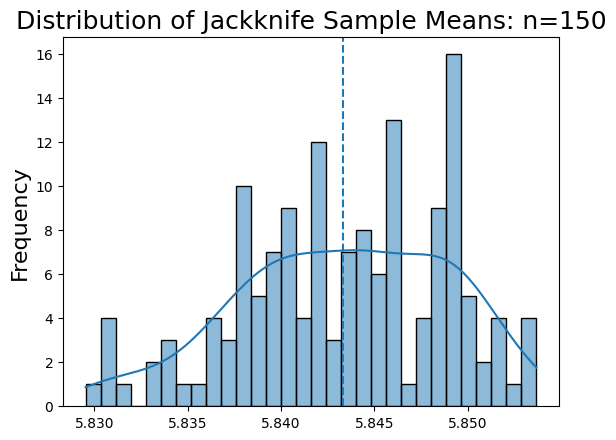

In [26]:
sns.histplot(jackknife_means, kde=True, label='Means of Jackknife Samples', bins=30)
plt.axvline(x=np.mean(jackknife_means), ymin=0, ymax=1, linestyle='--')
plt.title(f'Distribution of Jackknife Sample Means: n={len(iris)}', fontsize=18)
plt.ylabel('Frequency', fontsize=16)

print(f'Jackknife Mean: {np.mean(jackknife_means):.3}')
print(f'Jackknife Std: {np.std(jackknife_means):.3}')

If the dataset contains n observations, exactly how many jackknife samples are created?

- n jacknife samples.

## Part 3 --- Permutation Test

We will test whether sepal length differs significantly between two species.

For this task, use:

Versicolor
Virginica

### Task 5 --- Observed Statistic

Compute the observed difference in means:

difference = mean(Versicolor) − mean(Virginica)

In [32]:
mean_versicolor=np.mean(iris[iris['species']=='versicolor']['sepal_length'])
mean_virginica=np.mean(iris[iris['species']=='virginica']['sepal_length'])
difference=mean_versicolor-mean_virginica
print(f'Difference in Mean Sepal Length: {difference:.3}')

Difference in Mean Sepal Length: -0.652


### Task 6 --- Permutation Simulation

Run 1000 permutations

1. Combine the two species into one dataset
2. Shuffle (permute) the labels
3. Split the data back into two groups of the original sizes
4. Compute the difference in means
5. Store the result

Plot the permutation distribution

In [54]:
combined = iris[iris["species"].isin(["versicolor", "virginica"])]
combined_sl = combined["sepal_length"].to_numpy()
labels = combined["species"].to_numpy()

# Original group sizes
n_versicolor = np.sum(labels == "versicolor")
n_virginica = np.sum(labels == "virginica")

In [55]:
simu_diff = []
n_samples = 1000
n_treat = n_versicolor
print(n_treat)

50


In [56]:
for i in range(n_samples):
#Perform the permutation on all_weights
  perm_sample = np.random.permutation(combined_sl)
  #Assign the permuted samples to perm_treatment and perm_control
  perm_versicolor = perm_sample[:n_treat]
  perm_virginica = perm_sample[n_treat:]
  perm_diff = np.mean(perm_versicolor) - np.mean(perm_virginica)
  simu_diff.append(perm_diff)

In [57]:
#Use quantiles for define the 95% confidence interval.
upper = np.quantile(simu_diff, 0.95)
lower = np.quantile(simu_diff, 0.05)
print(lower, upper)

-0.2241999999999985 0.2159999999999993


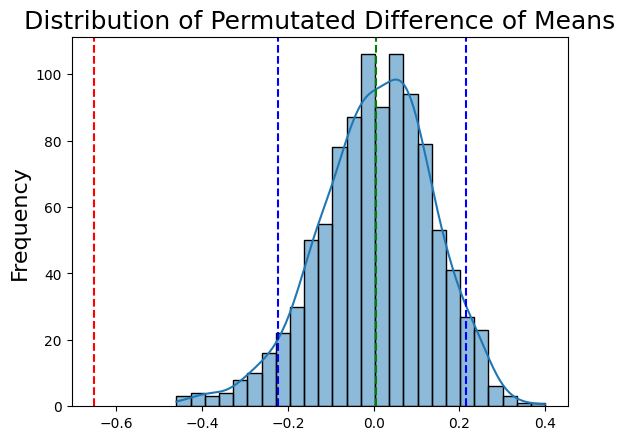

In [62]:
#Use quantiles for define the 95% confidence interval.
upper = np.quantile(simu_diff, 0.95)
lower = np.quantile(simu_diff, 0.05)

#Plot the distribution of permutated differences of means
sns.histplot(simu_diff, kde=True, label='Permutation')

plt.axvline(x=np.mean(simu_diff), ymin=0, ymax=1, color='green', linestyle='--')
plt.title('Distribution of Permutated Difference of Means', fontsize=18)
plt.ylabel('Frequency', fontsize=16)

# difference in means of original groups
plt.axvline(x = difference, ymin=0, ymax=1, color='red', linestyle='--')


# Confidence Interval
plt.axvline(x=lower, ymin=0, ymax=1, color='blue', linestyle='--')
plt.axvline(x=upper, ymin=0, ymax=1, color='blue', linestyle='--')

plt.show()

### Task 7 --- p-value

Compute the p-value:

p = (number of simulated differences ≥ observed difference) / (total simulations)

Interpret the result at α = 0.05

In [59]:
#Calculate the p-value
p_value = np.sum(np.abs(simu_diff) >= np.abs(difference)) / 1000
print(f'p-value: {p_value}')

p-value: 0.0


The result (p=0.0) indicates there is a statistically significant difference in mean sepal length between Irises of the Versicolor and Virginiana species.

### Questions:

- What is the null hypothesis (H0) in this specific test?

The null hypothesis is that there is no difference in mean sepal length between the two species. Since our p-value was very low we can reject this hypothesis.

- What does the permutation distribution represent in terms of random chance?

The distribution of differences in mean sepal length that would be expected if species were not relevant - if sepal length difference was basically random.

- Based on your p-value, do you reject or fail to reject the null hypothesis?

We reject the null. The difference in sepal_length is not due to random chance.